In [1]:
import random
from collections import defaultdict
from heapq import heappush, heappop
import os
import numpy as np

class Store:
    def __init__(self, items,parking_spaces=50, min_stock=20, num_cashiers=3, restock_multiplier=5):
        self.parking_spaces = parking_spaces
        self.available_spaces = parking_spaces
        self.min_stock = min_stock
        self.current_time = 0
        self.available_cashiers = 5
        self.pending_restocks = set()
        self.shopping_customers = set()
        self.num_cashiers = num_cashiers
        self.cashier_queues = [[] for _ in range(num_cashiers)]
        self.queue_log = []
        self.available_cashiers = [True] * num_cashiers

        # Initialize inventory and item popularity from input dictionary
        self.inventory = {item['name']: item['quantity'] for item in items}
        self.item_popularity = {item['name']: item['popularity'] for item in items}
        self.buy_prices = {item['name']: item['buy_price'] for item in items}
        self.sell_prices = {item['name']: item['sell_price'] for item in items}
        self.total_revenue = 0
        self.total_cost = 0
        self.total_profit = 0
        self.restock_multiplier = restock_multiplier
        
        total = sum(self.item_popularity.values())
        self.item_probs = {k: v/total for k, v in self.item_popularity.items()}
        self.customer_arrival_counter = 0
        self.customer_counter = 0
        self.customers_served = 0
        self.total_sales = defaultdict(int)
        self.event_queue = []

        # Distribution parameters
        self.max_car_arrival_rate = 0.8
        self.max_walking_arrival_rate = 0.4

        self.parking_time_mean = 5
        self.parking_time_std = 2
        self.parking_time_min = 1
        
        self.shopping_items_mean = 5
        self.shopping_items_std = 2
        self.shopping_items_min = 1
        
        self.shopping_time_min = 0.5
        self.shopping_time_max = 2
        
        self.checkout_base_time = 1
        self.checkout_per_item_min = 0.5
        self.checkout_per_item_max = 2
        
        self.exit_time_mean = 3
        self.exit_time_std = 1
        self.exit_time_min = 1
        
        self.restock_time_min = 120
        self.restock_time_max = 180


    def get_car_arrival_rate(self, hour):
        if 6 <= hour < 10:
            return 0.3
        elif 10 <= hour < 16:
            return 0.4
        elif 16 <= hour < 20:
            return 0.8
        elif 20 <= hour < 22:
            return 0.2
        else:
            return 0
        
    def get_walking_arrival_rate(self, hour):
        if 6 <= hour < 10:
            return 0.15
        elif 10 <= hour < 16:
            return 0.2
        elif 16 <= hour < 20:
            return 0.4
        elif 20 <= hour < 22:
            return 0.1
        else:
            return 0

    def select_queue(self, customer_data):
        # Option 1: Select the queue with the shortest length
        shortest_queue_idx = min(range(self.num_cashiers), 
                               key=lambda i: len(self.cashier_queues[i]))
        # Option 2: Select the queue with the least total items in it
        least_items_queue_idx = min(range(self.num_cashiers), 
                                    key=lambda i: sum(len(customer[1]) for customer in self.cashier_queues[i]))
        # Option 3: Select the queue with the earliest estimated finish time
        earliest_finish_queue_idx = min(range(self.num_cashiers), 
                                        key=lambda i: sum(self.checkout_base_time + len(customer[1]) * random.uniform(self.checkout_per_item_min, self.checkout_per_item_max) 
                                                           for customer in self.cashier_queues[i]))
        return shortest_queue_idx


    def schedule_next_arrival(self, current_time, by_car, limit_time):
        next_arrival = None
        self.customer_arrival_counter += 1
        if by_car:
            M = self.max_car_arrival_rate
            while True:
                current_time += random.expovariate(M)
                if current_time >= limit_time:
                    break
                car_arrival_rate = self.get_car_arrival_rate(int(current_time // 60))
                if random.uniform(0, 1) <= car_arrival_rate / M:
                    next_arrival = current_time
                    break
        else:
            M = self.max_walking_arrival_rate
            while True:
                current_time += random.expovariate(M)
                if current_time >= limit_time:
                    break
                walking_arrival_rate = self.get_walking_arrival_rate(int(current_time // 60))
                if random.uniform(0, 1) <= walking_arrival_rate / M:
                    next_arrival = current_time
                    break

        if next_arrival is not None:            
            heappush(self.event_queue, (next_arrival, "customer_arrival", by_car))

    def handle_customer_arrival(self, time, by_car):
        
        if by_car and self.available_spaces <= 0:
            heappush(self.event_queue, (time, "customer_turned_away", None))
            return
        
        self.customer_counter += 1
        customer_id = self.customer_counter
        self.shopping_customers.add(customer_id)
        if by_car:
            scarcity = max(1, (self.parking_spaces - self.available_spaces + 1))
            scarcity_scale = scarcity / self.parking_spaces

            min_time = self.parking_time_min
            max_time = min_time + 2 + 4 * scarcity_scale

            parking_time = max(1.1, random.uniform(min_time, max_time))

            self.available_spaces -= 1
            heappush(self.event_queue, (time + parking_time, "start_shopping", customer_id))
        else:
            heappush(self.event_queue, (time + 1, "start_shopping", customer_id))

    def handle_start_shopping(self, time, customer_id):
        # Rejection sampling: Gaussian greater than or equal to shopping_items_min
        while True:
            n_items = int(random.gauss(self.shopping_items_mean, self.shopping_items_std))
            if n_items >= self.shopping_items_min:
                break

        items_bought = []
        
        for _ in range(n_items):
            item = random.choices(list(self.item_probs.keys()), weights=list(self.item_probs.values()))[0]
            if self.inventory[item] > 0:
                items_bought.append(item)
                self.inventory[item] -= 1
                self.total_sales[item] += 1
                self.total_revenue += self.sell_prices[item]

        # Old shopping time calculation
        # shopping_time = sum(random.uniform(self.shopping_time_min, self.shopping_time_max) for _ in items_bought)

        # New shopping time calculation using Gaussian distribution with acceptance sampling
        n = len(items_bought)
        mu = n * (self.shopping_time_min + self.shopping_time_max) / 2
        sigma = np.sqrt(n * ((self.shopping_time_max - self.shopping_time_min) ** 2) / 12)

        min_total_time = n * self.shopping_time_min
        max_total_time = n * self.shopping_time_max

        while True:
            shopping_time = random.gauss(mu, sigma)
            if min_total_time <= shopping_time <= max_total_time:
                break
        heappush(self.event_queue, (time + shopping_time, "request_checkout", (customer_id, items_bought)))


    def handle_checkout_request(self, time, customer_data):
        customer_id, items = customer_data
        selected_cashier = self.select_queue(customer_data)
        
        self.shopping_customers.remove(customer_id)

        if self.available_cashiers[selected_cashier] and not self.cashier_queues[selected_cashier]:
            self.available_cashiers[selected_cashier] = False
            checkout_time = self.checkout_base_time + len(items) * random.uniform(self.checkout_per_item_min, self.checkout_per_item_max)
            heappush(self.event_queue, 
                    (time + checkout_time, "finish_checkout", 
                     (customer_id, self.available_spaces < self.parking_spaces, selected_cashier)))
        else:
            self.cashier_queues[selected_cashier].append(customer_data)
        
            total_queue_length = sum(len(queue) for queue in self.cashier_queues)

            self.queue_log.append(total_queue_length)
            

    def handle_checkout_finish(self, time, customer_data):
        customer_id, is_car, cashier_id = customer_data
        self.available_cashiers[cashier_id] = True
        self.customers_served += 1

        if self.cashier_queues[cashier_id]:
            next_customer = self.cashier_queues[cashier_id].pop(0)
            next_customer_id, items = next_customer
            self.available_cashiers[cashier_id] = False
            checkout_time = self.checkout_base_time + len(items) * random.uniform(0.5, 2)
            heappush(self.event_queue, 
                    (time + checkout_time, "finish_checkout", 
                     (next_customer_id, self.available_spaces < self.parking_spaces, cashier_id)))
            
        if is_car:
            exit_time = max(self.exit_time_min, random.gauss(self.exit_time_mean, self.exit_time_std))
            heappush(self.event_queue, (time + exit_time, "customer_exit", customer_id))
        else:
            heappush(self.event_queue, (time, "customer_exit", customer_id))

    def get_queue_stats(self):
        return {
            'queue_lengths': [len(q) for q in self.cashier_queues],
            'total_waiting': sum(len(q) for q in self.cashier_queues),
            'cashier_status': self.available_cashiers
        }

    def handle_customer_exit(self, time, customer_id):
        if self.available_spaces < self.parking_spaces:
            self.available_spaces += 1
    
    def handle_restock(self, time, item):
        restock_amount = self.item_popularity[item] * self.restock_multiplier
        self.inventory[item] += restock_amount
        self.pending_restocks.remove(item)
        self.total_cost += restock_amount * self.buy_prices[item]
        self.total_profit = self.total_revenue - self.total_cost


def run_simulation(items,parking_spaces=50, min_stock=20, num_cashiers=3,hours=16,restock_multiplier=5):
    
    if os.path.exists("simulation_log.md"):
        os.remove("simulation_log.md")

    store = Store(items,parking_spaces=parking_spaces,min_stock=min_stock,num_cashiers = num_cashiers,
                    restock_multiplier=restock_multiplier)
    
    open_time = 6 * 60
    end_time = open_time + hours * 60
    

    store.schedule_next_arrival(open_time, by_car=True,limit_time=end_time)
    store.schedule_next_arrival(open_time, by_car=False,limit_time=end_time)
    
    while store.event_queue:
        time, event_type, event_data = heappop(store.event_queue)
            
        store.current_time = time
       
        if event_type == "customer_arrival":
            # print(f"Time: {time:.2f} | Event: Customer Arrival | By Car: {event_data}")
            store.handle_customer_arrival(time, event_data)
            if time < end_time:
                store.schedule_next_arrival(time, event_data,limit_time=end_time)
        elif event_type == "start_shopping":
            # print(f"Time: {time:.2f} | Event: Start Shopping | Customer ID: {event_data}")
            store.handle_start_shopping(time, event_data)
        elif event_type == "request_checkout":
            # print(f"Time: {time:.2f} | Event: Request Checkout | Customer Data: {event_data}")
            store.handle_checkout_request(time, event_data)
        elif event_type == "finish_checkout":
            # print(f"Time: {time:.2f} | Event: Finish Checkout | Customer Data: {event_data}")
            store.handle_checkout_finish(time, event_data)
        elif event_type == "customer_exit":
            # print(f"Time: {time:.2f} | Event: Customer Exit | Customer ID: {event_data}")
            store.handle_customer_exit(time, event_data)
        elif event_type == "restock":
            # print(f"Time: {time:.2f} | Event: Restock | Item: {event_data}")
            store.handle_restock(time, event_data)

        # Log events to markdown file
        with open("simulation_log.md", "a") as log_file:
            if event_type == "customer_arrival":
                log_file.write(f"### Time: {time:.2f}\n**Event:** Customer Arrival\n**By Car:** {event_data}\n\n")
            elif event_type == "start_shopping":
                log_file.write(f"### Time: {time:.2f}\n**Event:** Start Shopping\n**Customer ID:** {event_data}\n\n")
            elif event_type == "request_checkout":
                customer_id, items = event_data
                log_file.write(f"### Time: {time:.2f}\n**Event:** Request Checkout\n**Customer ID:** {customer_id}\n**Items:** {', '.join(items)}\n\n")
            elif event_type == "finish_checkout":
                customer_id, is_car, cashier_id = event_data
                log_file.write(f"### Time: {time:.2f}\n**Event:** Finish Checkout\n**Customer ID:** {customer_id}\n**Cashier ID:** {cashier_id}\n**By Car:** {is_car}\n\n")
            elif event_type == "customer_exit":
                log_file.write(f"### Time: {time:.2f}\n**Event:** Customer Exit\n**Customer ID:** {event_data}\n\n")
            elif event_type == "restock":
                log_file.write(f"### Time: {time:.2f}\n**Event:** Restock\n**Item:** {event_data}\n\n")
        

        for item, quantity in store.inventory.items():
            if quantity <= store.min_stock and item not in store.pending_restocks:
                restock_time = random.uniform(30, 60)
                store.pending_restocks.add(item)
                heappush(store.event_queue, (time + restock_time, "restock", item))
                
    return {
        "customers_served": store.customers_served,
        "sales": dict(store.total_sales),
        "finish_time": time,
        "revenue": store.total_revenue,
        "costs": store.total_cost,
        "profit": store.total_profit,
        "queue_logs": store.queue_log,
        "number_of_arrivals": store.customer_arrival_counter,
    }

# Run simulation
def generate_items(num_items, min_quantity=50, max_quantity=200, min_popularity=1, max_popularity=10):
    item_names = [f"item{i}" for i in range(1, num_items)]
    while True:
        items = []
        for _ in range(10):
            name = random.choice(item_names)
            popularity = random.randint(min_popularity, max_popularity)
            quantity = random.randint(min_quantity, max_quantity)

            popularity_factor = 1 - ((popularity - min_popularity) / (max_popularity - min_popularity))
            
            buy_price = round(1.0 + (49.0 * popularity_factor), 2)
            
            # Generate sell price with 30-50%
            markup = random.uniform(1.3, 1.5)
            sell_price = round(buy_price * markup, 2)
            
            items.append({
            "name": name,
            "quantity": quantity,
            "popularity": popularity,
            "buy_price": buy_price,
            "sell_price": sell_price,
            })
        yield items

# Generate items
num_items = 10
item_generator = generate_items(num_items)
items = next(item_generator)

# Run the simulation
results = run_simulation(items, parking_spaces=50, min_stock=20, num_cashiers=5, hours=16, restock_multiplier=5)
# Print results
print("Simulation Results:")
print(f"Customers Served: {results['customers_served']}")
print(f"Sales: {results['sales']}")
print(f"Finish Time: {results['finish_time']:.2f}")
print(f"Revenue: {results['revenue']:.2f}")
print(f"Costs: {results['costs']:.2f}")
print(f"Profit: {results['profit']:.2f}")
print(f"Number of Arrivals: {results['number_of_arrivals']}")

Simulation Results:
Customers Served: 650
Sales: {'item6': 700, 'item3': 419, 'item8': 466, 'item5': 205, 'item9': 272}
Finish Time: 1356.10
Revenue: 59099.07
Costs: 33762.80
Profit: 25336.27
Number of Arrivals: 652


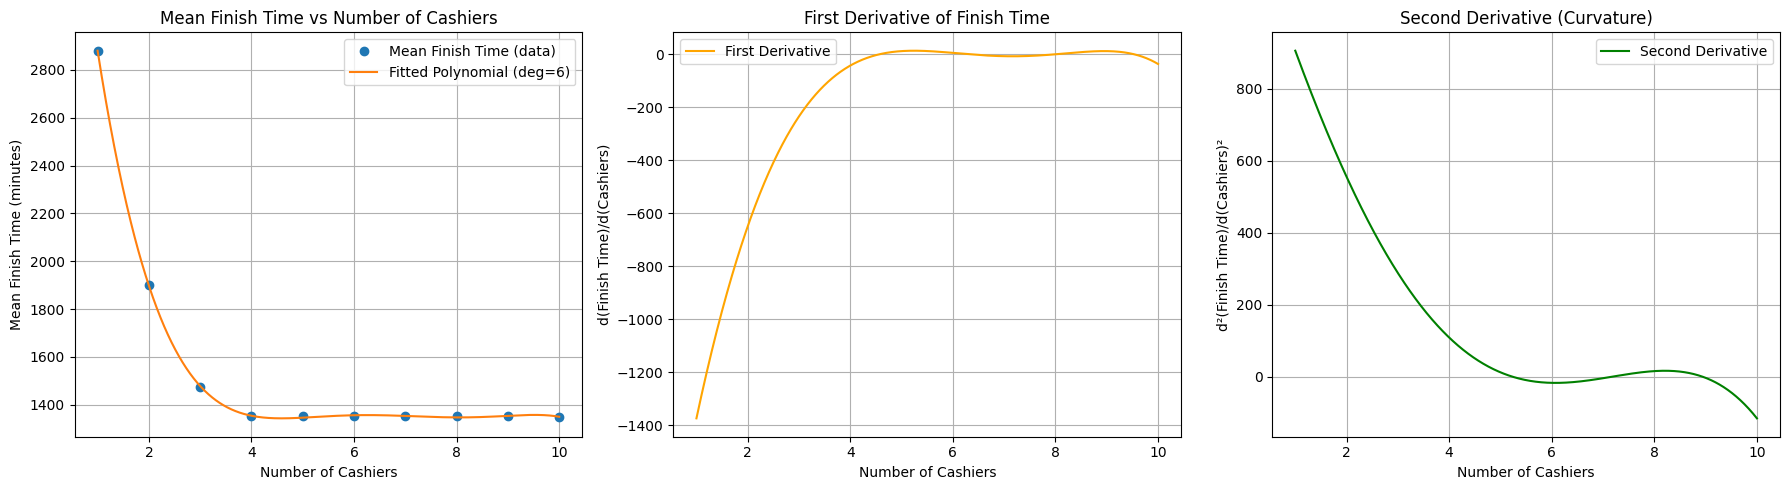

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.polynomial.polynomial import Polynomial

num_cashiers_range = range(1, 11)
min_simulations = 100
max_simulations = 500 
d = 8.0

# Generate items
num_items = 10
item_generator = generate_items(num_items)
items = next(item_generator)

mean_finish_times = []

for num_cashiers in num_cashiers_range:
    finish_samples = []

    for _ in range(min_simulations):
        result = run_simulation(
            items=items,
            num_cashiers=num_cashiers,
            hours=16
        )
        finish_samples.append(result['finish_time'])

    k = min_simulations
    while k < max_simulations:
        sample_mean = np.mean(finish_samples)
        sample_std = np.std(finish_samples, ddof=1)
        standard_error = sample_std / np.sqrt(k)

        if standard_error < d:
            break

        result = run_simulation(
            items=items,
            num_cashiers=num_cashiers,
            hours=16
        )
        finish_samples.append(result['finish_time'])
        k += 1

    mean_finish_times.append(np.mean(finish_samples))


x = np.array(list(num_cashiers_range))
y = np.array(mean_finish_times)


degree = 6
coeffs = np.polyfit(x, y, deg=degree)
poly = np.poly1d(coeffs)

first_derivative = poly.deriv()
second_derivative = poly.deriv(2)

x_dense = np.linspace(min(x), max(x), 1000)
y_dense = poly(x_dense)
dy_dx = first_derivative(x_dense)
d2y_dx2 = second_derivative(x_dense)

max_derivative_index = np.argmax(dy_dx)
max_derivative_x = x_dense[max_derivative_index]
max_derivative_y = dy_dx[max_derivative_index]

sign_changes = np.where(np.diff(np.sign(d2y_dx2)))[0]
inflection_points_x = x_dense[sign_changes]
inflection_points_y = y_dense[sign_changes]

# Plot all
plt.figure(figsize=(18, 5))

# Plot original function
plt.subplot(1, 3, 1)
plt.plot(x, y, 'o', label='Mean Finish Time (data)')
plt.plot(x_dense, y_dense, '-', label=f'Fitted Polynomial (deg={degree})')
plt.title('Mean Finish Time vs Number of Cashiers')
plt.xlabel('Number of Cashiers')
plt.ylabel('Mean Finish Time (minutes)')
plt.grid(True)
plt.legend()

# Plot first derivative
plt.subplot(1, 3, 2)
plt.plot(x_dense, dy_dx, color='orange', label='First Derivative')
plt.title('First Derivative of Finish Time')
plt.xlabel('Number of Cashiers')
plt.ylabel('d(Finish Time)/d(Cashiers)')
plt.grid(True)
plt.legend()

# Plot second derivative
plt.subplot(1, 3, 3)
plt.plot(x_dense, d2y_dx2, color='green', label='Second Derivative')
plt.title('Second Derivative (Curvature)')
plt.xlabel('Number of Cashiers')
plt.ylabel('d²(Finish Time)/d(Cashiers)²')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()




In [3]:
import numpy as np

def bootstrap(initial_sample, estimator=np.mean, number_bootstraps=1000):
    bootstrap_samples = []
    sample_size = len(initial_sample)
    for _ in range(number_bootstraps):
        sample = np.random.choice(initial_sample, size=sample_size, replace=True)
        bootstrap_samples.append(estimator(sample))
    return bootstrap_samples

def greater_than(array, n=16):
    return sum(1 for elem in array if elem > n)

def analyze_long_queues(num_simulations=100, queue_threshold=16, confidence_level=0.95, min_bootstrap=10000, estimator=np.mean):
    queue_observations = []
    
    # Generate items
    num_items = 10
    item_generator = generate_items(num_items)
    items = next(item_generator)

    for _ in range(num_simulations):
        result = run_simulation(
            items=items,
            num_cashiers=8,
            hours=16
        )
        queue_logs = result['queue_logs']

        long_queue_count = sum(1 for total_length in queue_logs
                     if total_length > queue_threshold)

        queue_observations.append(long_queue_count)


    print("Queue observations:", sum(queue_observations)/num_simulations)

    bootstrap_values = bootstrap(queue_observations, estimator=estimator, number_bootstraps=min_bootstrap)

    lower_percentile = ((1 - confidence_level) / 2) * 100
    upper_percentile = (1 - (1 - confidence_level) / 2) * 100
    ci_lower = np.percentile(bootstrap_values, lower_percentile)
    ci_upper = np.percentile(bootstrap_values, upper_percentile)

    return {
        'bootstrap_statistic_mean': np.mean(bootstrap_values),
        'confidence_interval': (ci_lower, ci_upper),
        'standard_error': np.std(bootstrap_values, ddof=1),
        'sample_size': num_simulations,
        'observations': queue_observations
    }

result = analyze_long_queues(estimator=greater_than)
print("\nFinal Analysis Result:")
for key, value in result.items():
    print(f"{key.replace('_', ' ').capitalize()}: {value}")

Queue observations: 4.46

Final Analysis Result:
Bootstrap statistic mean: 9.9764
Confidence interval: (np.float64(5.0), np.float64(16.0))
Standard error: 3.010506494750591
Sample size: 100
Observations: [0, 0, 12, 0, 0, 12, 33, 8, 0, 0, 16, 0, 20, 11, 5, 21, 3, 0, 0, 33, 7, 0, 0, 1, 20, 8, 0, 0, 1, 12, 0, 0, 0, 0, 0, 0, 20, 0, 0, 0, 17, 0, 0, 8, 0, 0, 0, 0, 1, 1, 0, 6, 0, 0, 0, 0, 0, 1, 0, 0, 9, 0, 0, 12, 35, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 31, 0, 8, 0, 0, 0, 0, 7, 0, 0, 0, 0, 0, 0, 0, 0, 4, 3, 0, 45, 7, 5, 0]


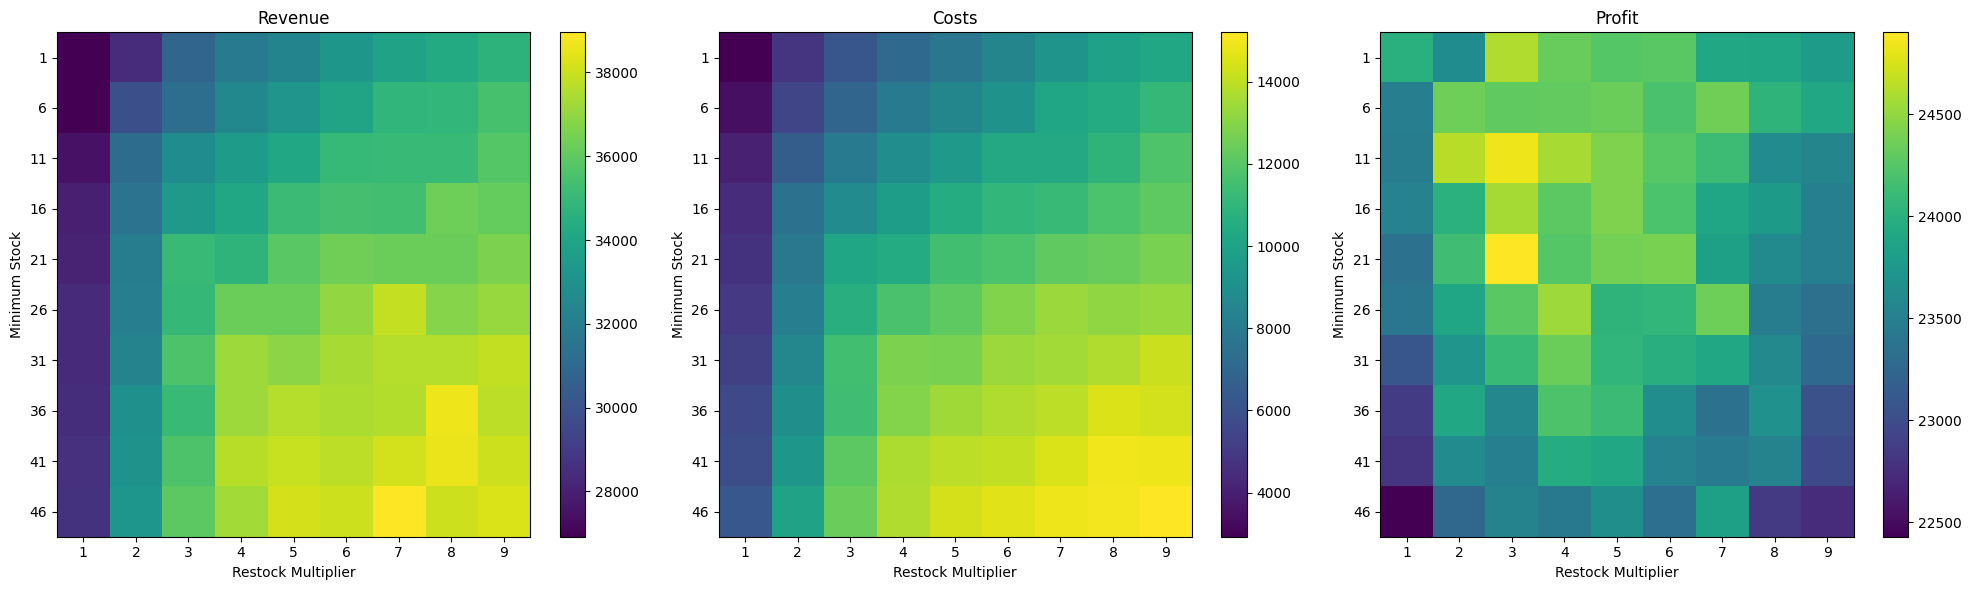

Optimal parameters (highest profit):
Minimum Stock: 21
Restock Multiplier: 3
Maximum Profit: $24900.78
Revenue: $35041.88
Costs: $10121.92

Worst parameters (lowest profit):
Minimum Stock: 46
Restock Multiplier: 1
Minimum Profit: $22429.44
Revenue: $28679.24
Costs: $6249.79


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for simulation
d = 200.0
min_simulations = 30
max_simulations = 500

# Parameter ranges
min_stock_range = range(1, 51, 5)
restock_mult_range = range(1, 10)

# Result matrices
revenues = np.zeros((len(min_stock_range), len(restock_mult_range)))
costs = np.zeros_like(revenues)
profits = np.zeros_like(revenues)

# Generate items once
num_items = 10
item_generator = generate_items(num_items)
items = next(item_generator)


# Run simulations with adaptive sampling
for i, min_stock in enumerate(min_stock_range):
    for j, restock_mult in enumerate(restock_mult_range):
        profit_samples = []
        revenue_samples = []
        cost_samples = []

        # Start with minimum number of simulations
        for _ in range(min_simulations):
            result = run_simulation(
                items=items,
                min_stock=min_stock,
                restock_multiplier=restock_mult,
                hours=16
            )
            profit_samples.append(result['profit'])
            revenue_samples.append(result['revenue'])
            cost_samples.append(result['costs'])

        # Continue until standard error < d or max_simulations reached
        k = min_simulations
        while k < max_simulations:
            sample_mean = np.mean(profit_samples)
            sample_std = np.std(profit_samples, ddof=1)
            standard_error = sample_std / np.sqrt(k)

            if standard_error < d:
                break

            result = run_simulation(
                items=items,
                min_stock=min_stock,
                restock_multiplier=restock_mult,
                hours=16
            )
            profit_samples.append(result['profit'])
            revenue_samples.append(result['revenue'])
            cost_samples.append(result['costs'])
            k += 1
            
        # Store means
        profits[i, j] = np.mean(profit_samples)
        revenues[i, j] = np.mean(revenue_samples)
        costs[i, j] = np.mean(cost_samples)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Heatmap: Revenue
im1 = axes[0].imshow(revenues, aspect='auto')
axes[0].set_title('Revenue')
axes[0].set_xlabel('Restock Multiplier')
axes[0].set_ylabel('Minimum Stock')
plt.colorbar(im1, ax=axes[0])
axes[0].set_xticks(range(len(restock_mult_range)))
axes[0].set_yticks(range(len(min_stock_range)))
axes[0].set_xticklabels(restock_mult_range)
axes[0].set_yticklabels(min_stock_range)

# Heatmap: Costs
im2 = axes[1].imshow(costs, aspect='auto')
axes[1].set_title('Costs')
axes[1].set_xlabel('Restock Multiplier')
axes[1].set_ylabel('Minimum Stock')
plt.colorbar(im2, ax=axes[1])
axes[1].set_xticks(range(len(restock_mult_range)))
axes[1].set_yticks(range(len(min_stock_range)))
axes[1].set_xticklabels(restock_mult_range)
axes[1].set_yticklabels(min_stock_range)

# Heatmap: Profits
im3 = axes[2].imshow(profits, aspect='auto')
axes[2].set_title('Profit')
axes[2].set_xlabel('Restock Multiplier')
axes[2].set_ylabel('Minimum Stock')
plt.colorbar(im3, ax=axes[2])
axes[2].set_xticks(range(len(restock_mult_range)))
axes[2].set_yticks(range(len(min_stock_range)))
axes[2].set_xticklabels(restock_mult_range)
axes[2].set_yticklabels(min_stock_range)

plt.tight_layout()
plt.show()

# Optimal parameters
max_profit_idx = np.unravel_index(np.argmax(profits), profits.shape)
min_profit_idx = np.unravel_index(np.argmin(profits), profits.shape)

print(f"Optimal parameters (highest profit):")
print(f"Minimum Stock: {min_stock_range[max_profit_idx[0]]}")
print(f"Restock Multiplier: {restock_mult_range[max_profit_idx[1]]}")
print(f"Maximum Profit: ${profits[max_profit_idx]:.2f}")
print(f"Revenue: ${revenues[max_profit_idx]:.2f}")
print(f"Costs: ${costs[max_profit_idx]:.2f}")

print(f"\nWorst parameters (lowest profit):")
print(f"Minimum Stock: {min_stock_range[min_profit_idx[0]]}")
print(f"Restock Multiplier: {restock_mult_range[min_profit_idx[1]]}")
print(f"Minimum Profit: ${profits[min_profit_idx]:.2f}")
print(f"Revenue: ${revenues[min_profit_idx]:.2f}")
print(f"Costs: ${costs[min_profit_idx]:.2f}")

650.75


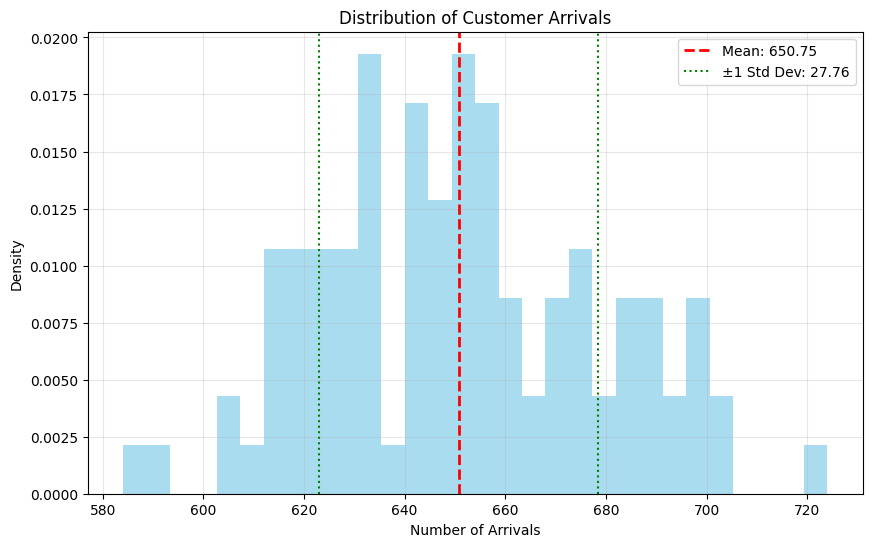

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_arrivals(num_simulations=100):
    arrival_counts = []
    min_simulations = 100
    max_simulations = 500 
    d = 3.0

    # Generate items
    num_items = 10
    item_generator = generate_items(num_items)
    items = next(item_generator)

    for _ in range(min_simulations):
        result = run_simulation(
            items, parking_spaces=50, min_stock=20, num_cashiers=5, hours=16, restock_multiplier=5
        )
        arrival_counts.append(result['number_of_arrivals'])

    k = min_simulations
    while k < max_simulations:
        sample_mean = np.mean(arrival_counts)
        sample_std = np.std(arrival_counts, ddof=1)
        standard_error = sample_std / np.sqrt(k)

        if standard_error < d:
            break

        result = run_simulation(
            items=items,
            num_cashiers=num_cashiers,
            hours=16
        )
        arrival_counts.append(result['number_of_arrivals'])
        k += 1
    
    print(np.mean(arrival_counts))
    plt.figure(figsize=(10, 6))
    arrival_counts = np.array(arrival_counts)
    plt.hist(arrival_counts, bins=30, density=True, alpha=0.7, color='skyblue')

    # Add mean line
    plt.axvline(np.mean(arrival_counts), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(arrival_counts):.2f}')

    # Add standard deviation range
    plt.axvline(np.mean(arrival_counts) - np.std(arrival_counts), color='green', linestyle=':', label=f'±1 Std Dev: {np.std(arrival_counts):.2f}')
    plt.axvline(np.mean(arrival_counts) + np.std(arrival_counts), color='green', linestyle=':')

    plt.title('Distribution of Customer Arrivals')
    plt.xlabel('Number of Arrivals')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

analyze_arrivals(num_simulations=1000)

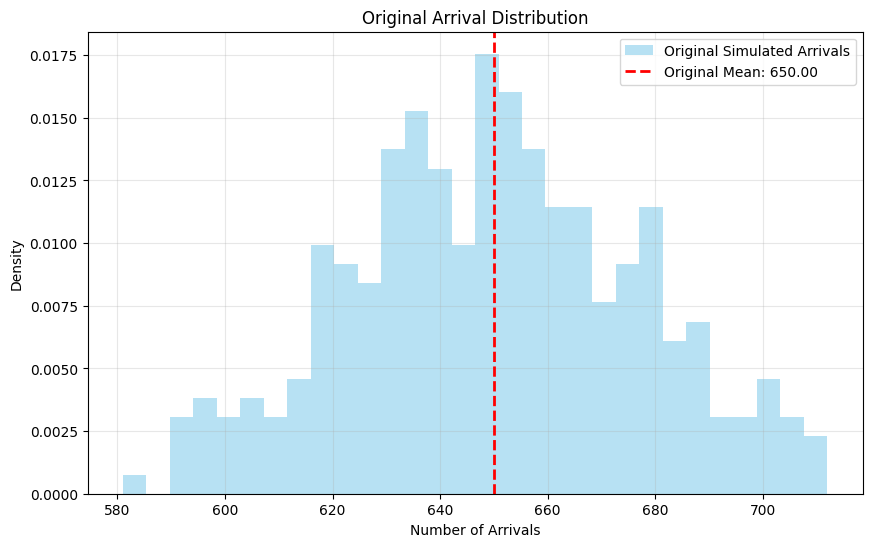

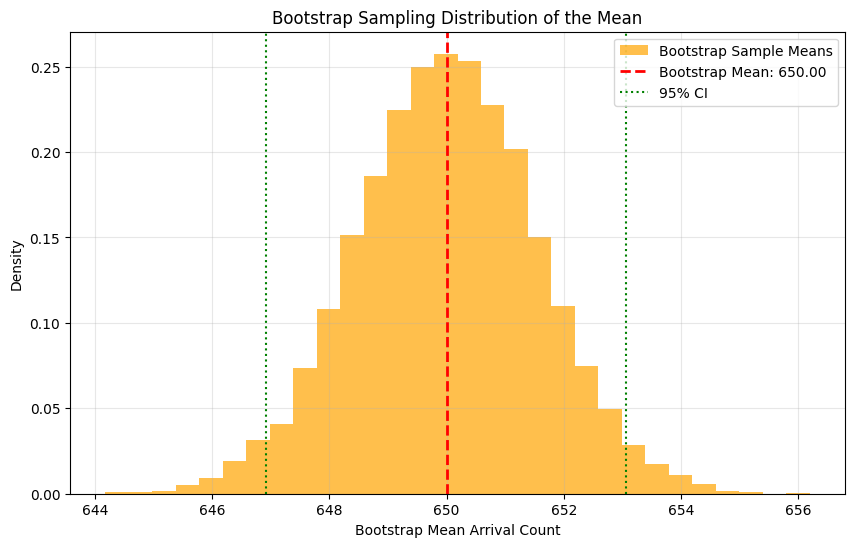

Original Mean: 650.00
Bootstrap Mean: 650.00
95% CI: (646.92, 653.06)


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_arrivals_with_bootstrap(num_simulations=300, num_bootstrap_samples=10000):
    arrival_counts = []
    d = 3.0

    num_items = 10
    item_generator = generate_items(num_items)
    items = next(item_generator)

    for _ in range(num_simulations):
        result = run_simulation(
            items=items,
            parking_spaces=50,
            min_stock=20,
            num_cashiers=5,
            hours=16,
            restock_multiplier=5
        )
        arrival_counts.append(result['number_of_arrivals'])

    arrival_counts = np.array(arrival_counts)

    bootstrap_means = []
    for _ in range(num_bootstrap_samples):
        resample = np.random.choice(arrival_counts, size=len(arrival_counts), replace=True)
        bootstrap_means.append(np.mean(resample))

    bootstrap_means = np.array(bootstrap_means)

    plt.figure(figsize=(10, 6))
    plt.hist(arrival_counts, bins=30, density=True, alpha=0.6, color='skyblue', label='Original Simulated Arrivals')
    plt.axvline(np.mean(arrival_counts), color='red', linestyle='dashed', linewidth=2, label=f'Original Mean: {np.mean(arrival_counts):.2f}')
    plt.grid(True, alpha=0.3)
    plt.title('Original Arrival Distribution')
    plt.xlabel('Number of Arrivals')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.hist(bootstrap_means, bins=30, density=True, alpha=0.7, color='orange', label='Bootstrap Sample Means')
    plt.axvline(np.mean(bootstrap_means), color='red', linestyle='dashed', linewidth=2, label=f'Bootstrap Mean: {np.mean(bootstrap_means):.2f}')
    plt.axvline(np.percentile(bootstrap_means, 2.5), color='green', linestyle=':', label='95% CI')
    plt.axvline(np.percentile(bootstrap_means, 97.5), color='green', linestyle=':')
    plt.grid(True, alpha=0.3)
    plt.title('Bootstrap Sampling Distribution of the Mean')
    plt.xlabel('Bootstrap Mean Arrival Count')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

    print(f"Original Mean: {np.mean(arrival_counts):.2f}")
    print(f"Bootstrap Mean: {np.mean(bootstrap_means):.2f}")
    print(f"95% CI: ({np.percentile(bootstrap_means, 2.5):.2f}, {np.percentile(bootstrap_means, 97.5):.2f})")

analyze_arrivals_with_bootstrap()


Shapiro-Wilk Test: stat = 0.9983, p = 0.4087


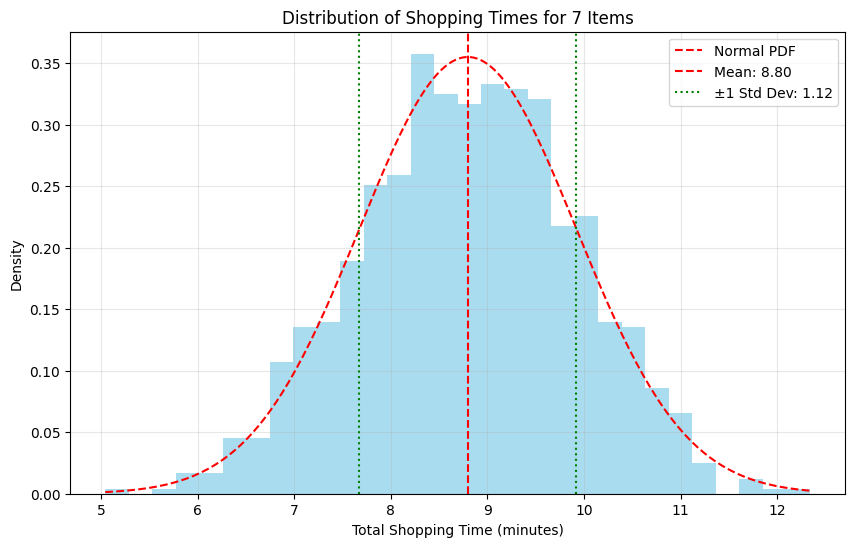

In [7]:
import random
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

def generate_shopping_times(n_items, t_min=0.5, t_max=2.0, num_simulations=1000):
    total_times = []
    for _ in range(num_simulations):
        times = [random.uniform(t_min, t_max) for _ in range(n_items)]
        total_times.append(sum(times))
    return total_times

n_items = 7
total_times = generate_shopping_times(n_items)

# Hypothesis Test: Does total_times follow a normal distribution?
# H0: The data follows a normal distribution
# H1: The data does not follow a normal distribution

# Shapiro-Wilk Test
shapiro_stat, shapiro_p = stats.shapiro(total_times)

print(f"Shapiro-Wilk Test: stat = {shapiro_stat:.4f}, p = {shapiro_p:.4f}")


plt.figure(figsize=(10, 6))
plt.hist(total_times, bins=30, density=True, alpha=0.7, color='skyblue')

# Overlay Normal PDF
x_vals = np.linspace(min(total_times), max(total_times), 200)
pdf_vals = stats.norm.pdf(x_vals, np.mean(total_times), np.std(total_times))
plt.plot(x_vals, pdf_vals, 'r--', label='Normal PDF')

plt.axvline(np.mean(total_times), color='red', linestyle='dashed', 
            label=f'Mean: {np.mean(total_times):.2f}')
plt.axvline(np.mean(total_times) + np.std(total_times), color='green', 
            linestyle=':', label=f'±1 Std Dev: {np.std(total_times):.2f}')
plt.axvline(np.mean(total_times) - np.std(total_times), color='green', linestyle=':')

plt.title(f'Distribution of Shopping Times for {n_items} Items')
plt.xlabel('Total Shopping Time (minutes)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()